In [2]:
from pathlib import Path

TRAIN_IMG_DIR  = Path(r"C:\Users\Nabil\.cache\kagglehub\datasets\alienxc137\earthvqa-semantic-segmentation-visual-question-ans\versions\1\Train-003\Train\images_png")
TRAIN_MASK_DIR = Path(r"C:\Users\Nabil\.cache\kagglehub\datasets\alienxc137\earthvqa-semantic-segmentation-visual-question-ans\versions\1\Train-003\Train\masks_png")

img_files  = sorted(p.name for p in TRAIN_IMG_DIR.glob("*.png"))
mask_files = sorted(p.name for p in TRAIN_MASK_DIR.glob("*.png"))

print(f"Total images: {len(img_files)}")
print(f"Total masks:  {len(mask_files)}")
print()
print("First 10 image filenames:", img_files[:10])
print()

both = sorted(set(img_files) & set(mask_files))
print(f"Images with a matching mask: {len(both)}")
print("First 10 usable filenames:", both[:10])

Total images: 2522
Total masks:  2522

First 10 image filenames: ['0.png', '1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png']

Images with a matching mask: 2522
First 10 usable filenames: ['0.png', '1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png']


In [3]:
import numpy as np
from PIL import Image
from pathlib import Path

TRAIN_IMG_DIR  = Path(r"C:\Users\Nabil\.cache\kagglehub\datasets\alienxc137\earthvqa-semantic-segmentation-visual-question-ans\versions\1\Train-003\Train\images_png")
TRAIN_MASK_DIR = Path(r"C:\Users\Nabil\.cache\kagglehub\datasets\alienxc137\earthvqa-semantic-segmentation-visual-question-ans\versions\1\Train-003\Train\masks_png")

OUT_DIR = Path(r"D:\amir lab\RS-Vamba-main\fusion\outputs\diagram_assets")
OUT_DIR.mkdir(parents=True, exist_ok=True)

LOVEDA_PALETTE = {
    0: (255, 255, 255),   # background
    1: (255, 0,   0),     # building
    2: (255, 255, 0),     # road
    3: (0,   0,   255),   # water
    4: (159, 129, 183),   # barren
    5: (0,   255, 0),     # forest
    6: (255, 195, 128),   # agriculture
    7: (128, 128, 128),   # other / class 7
    8: (0,   0,   0),     # class 8 (the one that caused the earlier CUDA bug)
}

def colorize_mask(mask_arr):
    h, w = mask_arr.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls_id, color in LOVEDA_PALETTE.items():
        rgb[mask_arr == cls_id] = color
    return Image.fromarray(rgb)

img_id = "2304.png"

img  = Image.open(TRAIN_IMG_DIR / img_id).convert('RGB').resize((256, 256))
mask = Image.open(TRAIN_MASK_DIR / img_id)
mask_arr = np.array(mask)
print("Unique classes in this mask:", np.unique(mask_arr))

mask_colored = colorize_mask(mask_arr).resize((256, 256), Image.NEAREST)

img.save(OUT_DIR / f"{img_id}_rgb.png")
mask_colored.save(OUT_DIR / f"{img_id}_mask_colored.png")
print(f"Saved paired example to {OUT_DIR}")

Unique classes in this mask: [1 2 3 5 6]
Saved paired example to D:\amir lab\RS-Vamba-main\fusion\outputs\diagram_assets


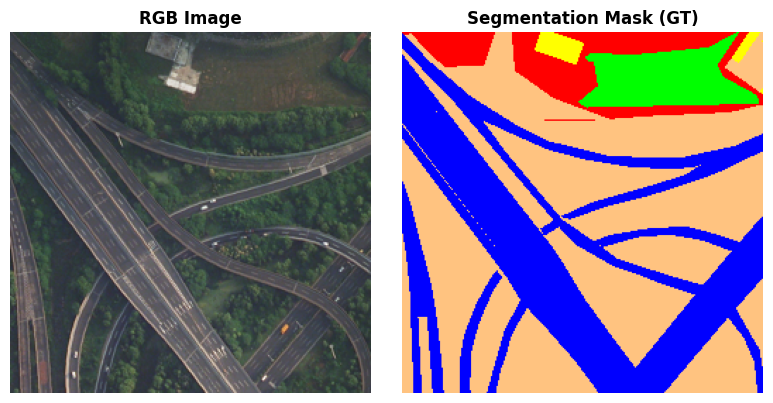

Saved combined figure to D:\amir lab\RS-Vamba-main\fusion\outputs\diagram_assets\2304.png_paired_figure.png


In [4]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

OUT_DIR = Path(r"D:\amir lab\RS-Vamba-main\fusion\outputs\diagram_assets")
img_id = "2304.png"   # use whatever filename you actually used in the colorize script

rgb   = Image.open(OUT_DIR / f"{img_id}_rgb.png")
mask  = Image.open(OUT_DIR / f"{img_id}_mask_colored.png")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(rgb)
axes[0].set_title("RGB Image", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mask)
axes[1].set_title("Segmentation Mask (GT)", fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / f"{img_id}_paired_figure.png", dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved combined figure to {OUT_DIR / (img_id + '_paired_figure.png')}")

In [ ]:
VAL_IMG_DIR = Path(r"C:\\Users\\Nabil\\.cache\\kagglehub\\datasets\\alienxc137\\earthvqa-semantic-segmentation-visual-question-ans\\versions\\1\\Val-002\\Val\\images_png")

In [13]:
import shutil
from pathlib import Path
VAL_IMG_DIR = Path(r"C:\\Users\\Nabil\\.cache\\kagglehub\\datasets\\alienxc137\\earthvqa-semantic-segmentation-visual-question-ans\\versions\\1\\Val-002\\Val\\images_png")
FUSION_DIR    = Path(r"D:\amir lab\RS-Vamba-main\fusion")

img_id = "3811.png"

src = VAL_IMG_DIR / img_id
dst = FUSION_DIR / img_id

if not src.exists():
    print(f"NOT FOUND: {src}")
    print("Check the filename — list_val_files.py can confirm what actually exists.")
else:
    shutil.copy(src, dst)
    print(f"Saved raw image to {dst}")

Saved raw image to D:\amir lab\RS-Vamba-main\fusion\3811.png
